# Lesson 22: KDD Cup 1999 network intrusion detection

This notebook uses the [KDD Cup 1999 network intrusion dataset](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html), a benchmark dataset built from simulated network traffic. Each row is one network connection described by 41 features: 38 numerical (e.g. duration, bytes transferred, number of failed login attempts) and 3 categorical (protocol type, network service, and connection flag). Connections are labeled either `normal` or as one of several attack types.

Although labels exist, we treat this as an **unsupervised** problem: models are trained with features only, no access to labels. This mirrors the real-world scenario where some labeled historical anomalies may exist for evaluation, but the model must detect new anomalous network traffic without supervision. Labels are revealed at the end to evaluate results.

## 1. Notebook set up

### 1.1. Imports

In [1]:
import math

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from matplotlib.patches import Patch
# from mlxtend.frequent_patterns import apriori, association_rules
# from mlxtend.preprocessing import TransactionEncoder
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import fetch_kddcup99
from sklearn.decomposition import PCA #, TruncatedSVD
from sklearn.ensemble import IsolationForest
# from sklearn.manifold import TSNE
# from sklearn.cluster import FeatureAgglomeration
# from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score
# from sklearn.neighbors import LocalOutlierFactor
# from sklearn.svm import OneClassSVM
# from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

### 1.2. Data loading

In [2]:
# Load the complete KDD Cup 1999 dataset from SKlearn
kdd = fetch_kddcup99(percent10=False, as_frame=True)
kdd_df = kdd.data
    
print(f'Raw data is: {type(kdd)}')
print(f'Raw data contains: {", ".join(list(kdd.keys()))}\n')
print(f'DESCR:\n{kdd.DESCR}')

kdd_df.head().T

Raw data is: <class 'sklearn.utils._bunch.Bunch'>
Raw data contains: data, target, frame, target_names, feature_names, DESCR

DESCR:
.. _kddcup99_dataset:

Kddcup 99 dataset
-----------------

The KDD Cup '99 dataset was created by processing the tcpdump portions
of the 1998 DARPA Intrusion Detection System (IDS) Evaluation dataset,
created by MIT Lincoln Lab [2]_. The artificial data (described on the `dataset's
homepage <https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html>`_) was
generated using a closed network and hand-injected attacks to produce a
large number of different types of attack with normal activity in the
background. As the initial goal was to produce a large training set for
supervised learning algorithms, there is a large proportion (80.1%) of
abnormal data which is unrealistic in real world, and inappropriate for
unsupervised anomaly detection which aims at detecting 'abnormal' data, i.e.:

* qualitatively different from normal data
* in large minority among the

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,b'tcp',b'tcp',b'tcp',b'tcp',b'tcp'
service,b'http',b'http',b'http',b'http',b'http'
flag,b'SF',b'SF',b'SF',b'SF',b'SF'
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


In [3]:
kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898431 entries, 0 to 4898430
Data columns (total 41 columns):
 #   Column                       Dtype 
---  ------                       ----- 
 0   duration                     object
 1   protocol_type                object
 2   service                      object
 3   flag                         object
 4   src_bytes                    object
 5   dst_bytes                    object
 6   land                         object
 7   wrong_fragment               object
 8   urgent                       object
 9   hot                          object
 10  num_failed_logins            object
 11  logged_in                    object
 12  num_compromised              object
 13  root_shell                   object
 14  su_attempted                 object
 15  num_root                     object
 16  num_file_creations           object
 17  num_shells                   object
 18  num_access_files             object
 19  num_outbound_cmds            obj

In [4]:
# Preserve for final evaluation
labels = kdd.target
print(f'Labels contain: {", ".join(list(set(labels.astype(str))))}')

Labels contain: normal., land., buffer_overflow., loadmodule., satan., neptune., warezmaster., teardrop., rootkit., pod., portsweep., nmap., smurf., spy., perl., ipsweep., warezclient., back., guess_passwd., phf., multihop., ftp_write., imap.


## 2. Data cleaning

### 2.1. Labels

In [5]:
# Convert to string
labels = labels.astype(str)

### 2.2. Row deduplication

The original data contains a large number of duplicated rows - this can be trouble for things like isolation forest. The traffic pattern itself may be anomalous, but if it is repeated a large number of times those repeats make it appear to be normal traffic.

In [6]:
print(f'Duplicate rows: {kdd_df.duplicated().sum()}')

Duplicate rows: 3823457


De-duplicate the rows and add a feature indicating how many times each unique connection vector appeared in the original data.

In [7]:
# Temporarily add back the labels so row removal is consistent
kdd_df['labels'] = labels

# Remove duplicate rows and count occurrences
counts = kdd_df.groupby(kdd_df.columns.tolist(), as_index=False).size()
counts = counts.rename(columns={'size': 'occurrences'})
kdd_df = kdd_df.drop_duplicates().merge(counts, on=kdd_df.columns.to_list(), how='left')

# Update and then remove the labels
labels = kdd_df['labels']
kdd_df.drop('labels', axis=1, inplace=True)

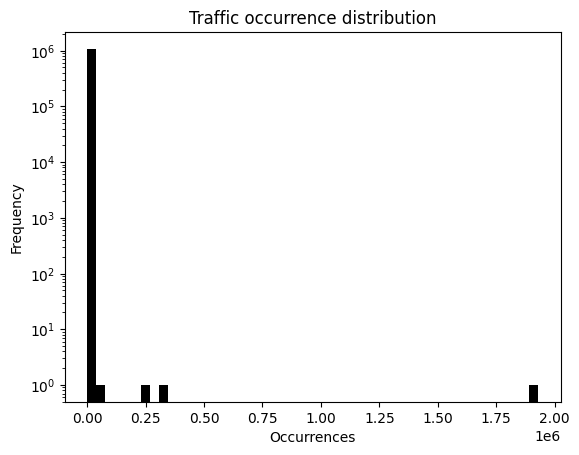

In [8]:
plt.title('Traffic occurrence distribution')
plt.hist(kdd_df['occurrences'], bins=50, color='black')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

### 2.3. Feature definitions

In [9]:
# Define string, int and float features
string_features = [
    'protocol_type', 'service', 'flag'
]

int_features = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'dst_host_count',
    'dst_host_srv_count',
    'occurrences',
]

float_features = [
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]


In [10]:
# Clean binary encoded features
kdd_df[string_features] = kdd_df[string_features].astype('string')

# Set feature data types
kdd_df[string_features] = kdd_df[string_features].astype('category')
kdd_df[int_features] = kdd_df[int_features].astype('int')
kdd_df[float_features] = kdd_df[float_features].astype('float')

kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   duration                     1074992 non-null  int64   
 1   protocol_type                1074992 non-null  category
 2   service                      1074992 non-null  category
 3   flag                         1074992 non-null  category
 4   src_bytes                    1074992 non-null  int64   
 5   dst_bytes                    1074992 non-null  int64   
 6   land                         1074992 non-null  int64   
 7   wrong_fragment               1074992 non-null  int64   
 8   urgent                       1074992 non-null  int64   
 9   hot                          1074992 non-null  int64   
 10  num_failed_logins            1074992 non-null  int64   
 11  logged_in                    1074992 non-null  int64   
 12  num_compromised              1074992 no

In [11]:
kdd_df.head().T

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,tcp,tcp,tcp,tcp,tcp
service,http,http,http,http,http
flag,SF,SF,SF,SF,SF
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


## 3. EDA & pre-processing

### 3.1. String (categorical) features

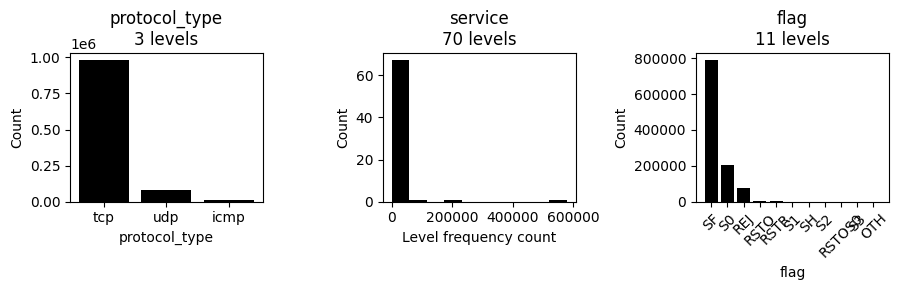

In [12]:
fig, axes = plt.subplots(
    math.ceil(len(string_features) / 3),
    3,
    figsize=(9, math.ceil(len(string_features) / 3) * 3)
)

axes = axes.flatten()

for i, feature in enumerate(string_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} levels')

    if len(counts) > 20:
        axes[i].hist(counts.values, bins=10, color='black')
        axes[i].set_xlabel('Level frequency count')
        axes[i].set_ylabel('Count')

    else:
        axes[i].bar(counts.index.astype(str), counts.values, color='black')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

        if len(counts) > 10:
            axes[i].tick_params(axis='x', rotation=45)

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

Thinking we should use try one-hot here - we are going to end up with > 80 features, but we can just SVD them later if needed. This approach preserves the information content better than hashing and does not impose arbitrary order like ordinal encoding.

In [13]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(kdd_df[string_features])

encoded_feature_names = encoder.get_feature_names_out()

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoded_feature_names
)

kdd_df = pd.concat([kdd_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
kdd_df.drop(string_features, axis=1, inplace=True)
kdd_df[encoded_feature_names] = kdd_df[encoded_feature_names].astype('int')

### 3.2. Integer (count) features

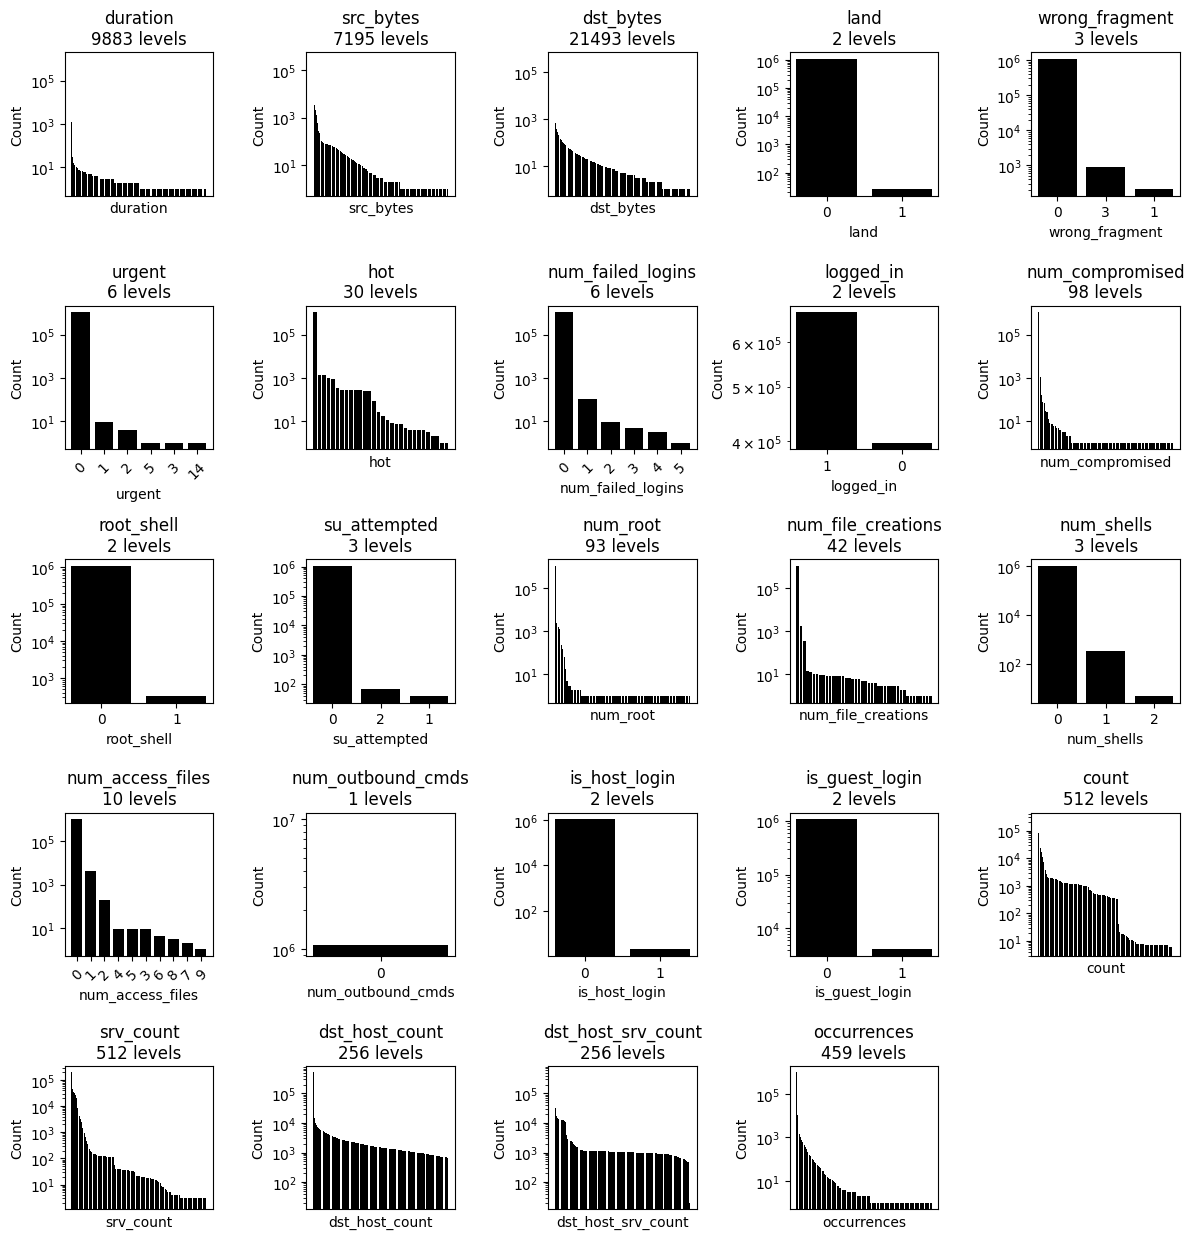

In [14]:
fig, axes = plt.subplots(
    math.ceil(len(int_features) / 5),
    5,
    figsize=(12, math.ceil(len(int_features) / 5) * 2.5)
)

axes = axes.flatten()

for i, feature in enumerate(int_features):

    counts = kdd_df[feature].value_counts()
    axes[i].set_title(f'{feature}\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

OK - a few things jump out right away:

1. The integer features are a mix of high and low cardinality. Some are binary, while at the other extreme some have thousands of levels.
2. Most low cardinality features are dominated by one category (see `land` or `wrong_fragment` and note log scale y-axis), while high cardinality features often have many levels that show up only a few times, and some that show up many times (see `num_root` or `num_compromised` and again note log y-axis).
3. `num_outbound_cmds` is constant and can be dropped.

Let's break the integer features into finer categories so we can handle the cases differently.

1. **Binary** (ex: `land`, `logged_in`): leave as 0/1 encoding and cast to bool.
2. **Low cardinality count** (ex: `num_failed_logins`): leave as ordinal encoding.
3. **Skewed high cardinality count** (ex: `src_bytes`): treat as continuous, power transform.

In [15]:
# Drop constant feature
kdd_df.drop('num_outbound_cmds', axis=1, inplace=True)
int_features.remove('num_outbound_cmds')

In [16]:
# New feature subset definitions for integer features
binary_features = []
low_cardinality = []
high_cardinality = []

for feature in int_features:
    if kdd_df[feature].nunique() == 2:
        binary_features.append(feature)

    elif kdd_df[feature].nunique() < 50:
        low_cardinality.append(feature)

    elif kdd_df[feature].nunique() >= 50:
        high_cardinality.append(feature)

    else:
        print(f"Don't know what to do with {feature}")

print(f'Binary features: {", ".join(binary_features)}\n')
print(f'Low cardinality features: {", ".join(low_cardinality)}\n')
print(f'High cardinality features: {", ".join(high_cardinality)}\n')
print(f'Total integer features: {len(binary_features + low_cardinality + high_cardinality)}')

Binary features: land, logged_in, root_shell, is_host_login, is_guest_login

Low cardinality features: wrong_fragment, urgent, hot, num_failed_logins, su_attempted, num_file_creations, num_shells, num_access_files

High cardinality features: duration, src_bytes, dst_bytes, num_compromised, num_root, count, srv_count, dst_host_count, dst_host_srv_count, occurrences

Total integer features: 23


In [17]:
# Set type for binary features
kdd_df[binary_features] = kdd_df[binary_features].astype('bool')

In [18]:
# Result
kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Columns: 122 entries, duration to flag_SH
dtypes: bool(5), float64(15), int64(102)
memory usage: 964.7 MB


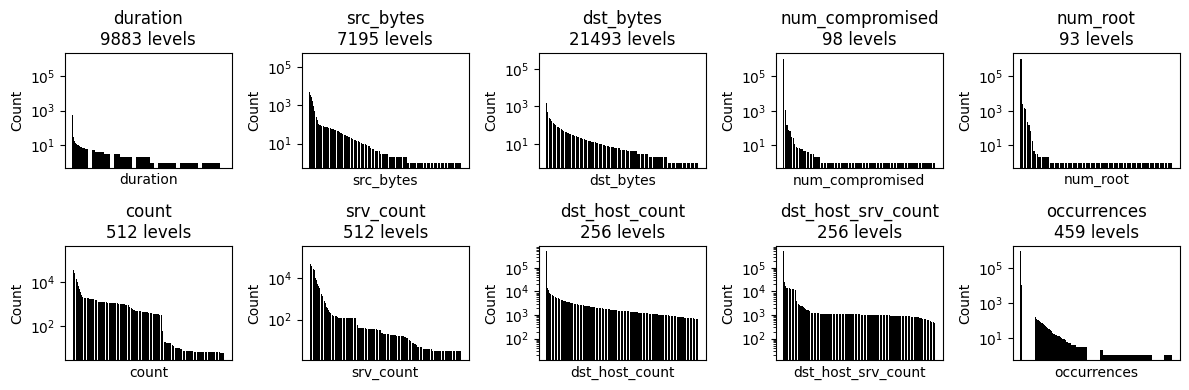

In [19]:
fig, axes = plt.subplots(
    math.ceil(len(high_cardinality) / 5),
    5,
    figsize=(12, math.ceil(len(high_cardinality) / 5) * 2)
)

axes = axes.flatten()

for i, feature in enumerate(high_cardinality):

    counts = kdd_df[feature].value_counts()
    axes[i].set_title(f'{feature}\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

Last transformation - let's frequency encode the high cardinality integer features.

In [20]:
for feature in high_cardinality:
    # Map each value to its frequency count in the full dataset
    freq_map = kdd_df[feature].value_counts()
    kdd_df[f'{feature}_freq'] = kdd_df[feature].map(freq_map)

/tmp/ipykernel_3082551/2511217839.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdd_df[f'{feature}_freq'] = kdd_df[feature].map(freq_map)
/tmp/ipykernel_3082551/2511217839.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  kdd_df[f'{feature}_freq'] = kdd_df[feature].map(freq_map)
/tmp/ipykernel_3082551/2511217839.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

In [21]:
kdd_df[[f'{feature}_freq' for feature in high_cardinality]].info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 10 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   duration_freq            1074992 non-null  int64
 1   src_bytes_freq           1074992 non-null  int64
 2   dst_bytes_freq           1074992 non-null  int64
 3   num_compromised_freq     1074992 non-null  int64
 4   num_root_freq            1074992 non-null  int64
 5   count_freq               1074992 non-null  int64
 6   srv_count_freq           1074992 non-null  int64
 7   dst_host_count_freq      1074992 non-null  int64
 8   dst_host_srv_count_freq  1074992 non-null  int64
 9   occurrences_freq         1074992 non-null  int64
dtypes: int64(10)
memory usage: 82.0 MB


In [22]:
kdd_df.head().T

,0,1,2,3,4
duration,0,0,0,0,0
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,False,False,False,False,False
wrong_fragment,0,0,0,0,0
...,...,...,...,...,...
count_freq,262837,79334,262837,79334,49257
srv_count_freq,194026,113854,194026,113854,64568
dst_host_count_freq,20,16259,14263,11148,10221
dst_host_srv_count_freq,20,32254,25915,16903,14945


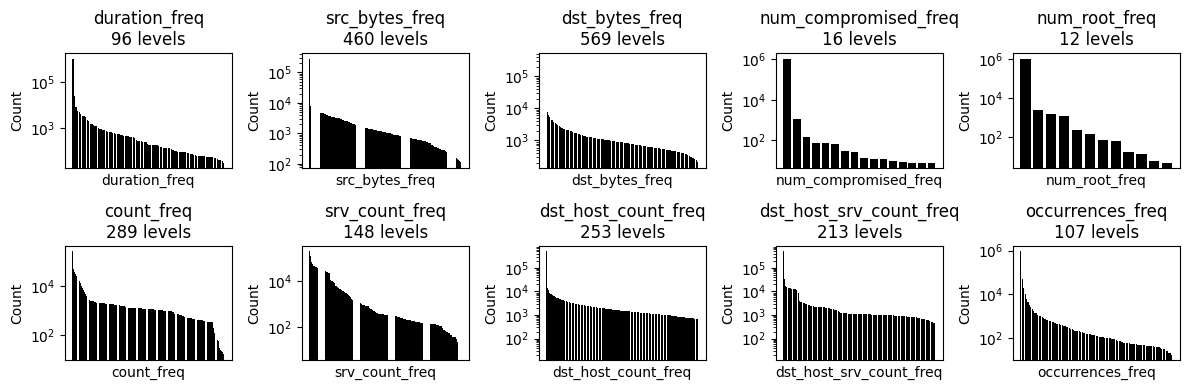

In [23]:
fig, axes = plt.subplots(
    math.ceil(len(high_cardinality) / 5),
    5,
    figsize=(12, math.ceil(len(high_cardinality) / 5) * 2)
)

axes = axes.flatten()

for i, feature in enumerate(high_cardinality):

    counts = kdd_df[f'{feature}_freq'].value_counts()
    axes[i].set_title(f'{feature}_freq\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(f'{feature}_freq')
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

### 3.3. Float (continuous) features

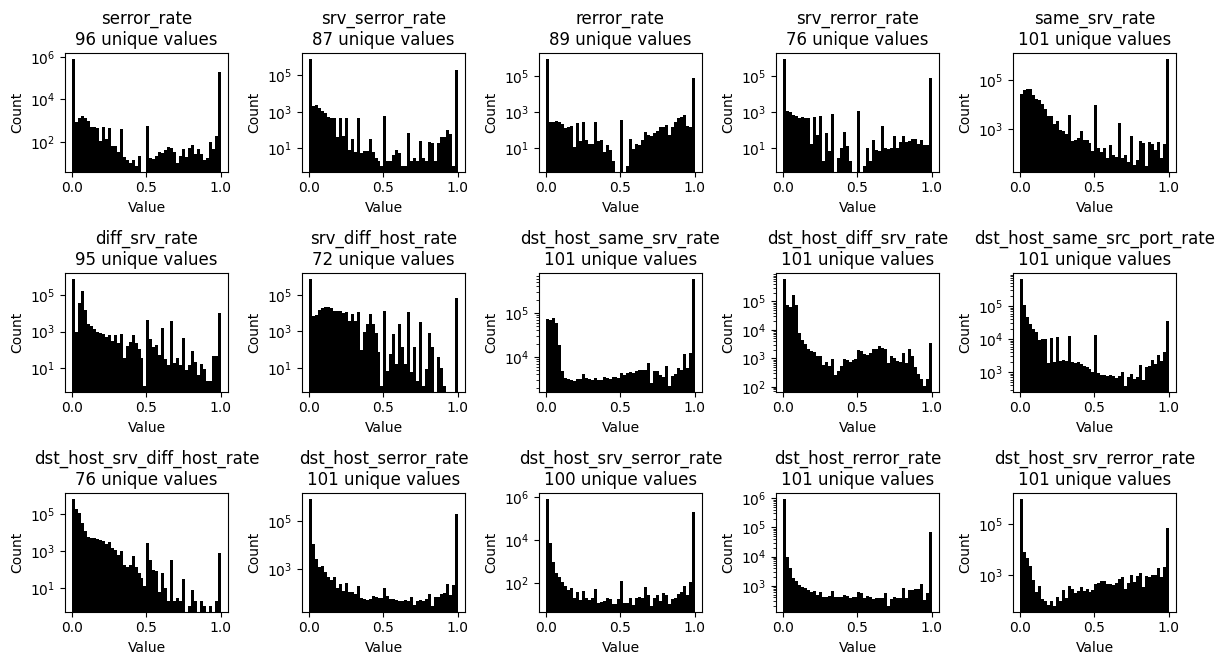

In [24]:
n_cols = 5

fig, axes = plt.subplots(
    math.ceil(len(float_features) / n_cols),
    n_cols,
    figsize=(12, math.ceil(len(float_features) / n_cols) * 2.25)
)

axes = axes.flatten()

for i, feature in enumerate(float_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} unique values')

    axes[i].hist(kdd_df[feature], bins=50, color='black')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()
plt.show()

Some of these have considerably lower cardinality than our integer/'categorical' features. But, the values are more spread over the ranges. Let's keep it simple and just power transform.

In [25]:
# Power transform the continuous features
transformer = PowerTransformer(method='yeo-johnson', standardize=True)
kdd_df[float_features] = transformer.fit_transform(kdd_df[float_features])

In [26]:
kdd_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 132 columns):
 #    Column                       Dtype  
---   ------                       -----  
 0    duration                     int64  
 1    src_bytes                    int64  
 2    dst_bytes                    int64  
 3    land                         bool   
 4    wrong_fragment               int64  
 5    urgent                       int64  
 6    hot                          int64  
 7    num_failed_logins            int64  
 8    logged_in                    bool   
 9    num_compromised              int64  
 10   root_shell                   bool   
 11   su_attempted                 int64  
 12   num_root                     int64  
 13   num_file_creations           int64  
 14   num_shells                   int64  
 15   num_access_files             int64  
 16   is_host_login                bool   
 17   is_guest_login               bool   
 18   count                        in

In [27]:
display(kdd_df.isna().sum())

duration                   0
src_bytes                  0
dst_bytes                  0
land                       0
wrong_fragment             0
                          ..
count_freq                 0
srv_count_freq             0
dst_host_count_freq        0
dst_host_srv_count_freq    0
occurrences_freq           0
Length: 132, dtype: int64

## 4. Isolation forest

In [28]:
contamination = 0.01

iso_forest = IsolationForest(contamination=contamination, random_state=315)
iso_forest_labels = iso_forest.fit_predict(kdd_df)

n_outliers = (iso_forest_labels == -1).sum()
print(f'Isolation Forest: {n_outliers} anomalies detected ({n_outliers / len(iso_forest_labels):.1%})')

Isolation Forest: 10750 anomalies detected (1.0%)


#### 3.7.3. Results visualization

In [40]:
# Standard scale for PCA projection
scaler = StandardScaler()
scaled_kdd_df = pd.DataFrame(scaler.fit_transform(kdd_df), columns=kdd_df.columns)

# Project to 2D for visualization
pca_vis = PCA(n_components=2, random_state=315)
kdd_vis_df = pd.DataFrame(pca_vis.fit_transform(scaled_kdd_df), columns=['PC1', 'PC2'])

# Convert sklearn's -1/1 output to 0/1
def to_binary(labels):
    return (np.array(labels) == -1).astype(int)

kdd_vis_df['Anomaly'] = to_binary(iso_forest_labels)
kdd_vis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   PC1      1074992 non-null  float64
 1   PC2      1074992 non-null  float64
 2   Anomaly  1074992 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 24.6 MB


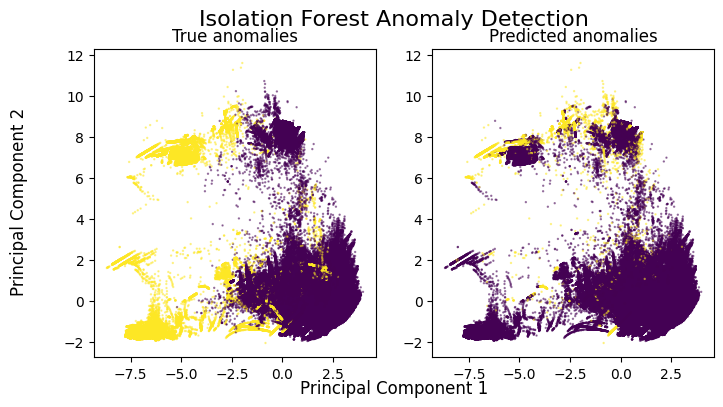

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Isolation Forest Anomaly Detection', fontsize=16)
fig.supxlabel('Principal Component 1', fontsize=12)
fig.supylabel('Principal Component 2', fontsize=12)

encoded_labels = [0 if label == 'normal.' else 1 for label in labels]

axes[0].set_title('True anomalies')
axes[1].set_title('Predicted anomalies')
axes[0].scatter(kdd_vis_df['PC1'], kdd_vis_df['PC2'], c=encoded_labels, s=0.5, alpha=0.5)
axes[1].scatter(kdd_vis_df['PC1'], kdd_vis_df['PC2'], c=kdd_vis_df['Anomaly'], s=0.5, alpha=0.5)

plt.show()